1. Introdução

A análise de crédito é uma atividade importante para instituições financeiras, pois permite avaliar o perfil dos clientes e identificar o risco relacionado à concessão de crédito. Com o aumento da quantidade de informações disponíveis, o uso de dados pode auxiliar na criação de análises mais eficientes e apoiar a tomada de decisões.
Neste projeto, desenvolvido para a empresa Data Girls Finance, será realizada uma análise utilizando técnicas de Ciência de Dados e Machine Learning com o objetivo de criar um modelo capaz de classificar o score de crédito dos clientes.
Para isso, será utilizado o dataset 'Credit Score Classification', que contém informações relacionadas ao perfil financeiro dos clientes, como renda, histórico de pagamentos, dívidas, empréstimos, utilização de crédito e outros comportamentos financeiros. A partir desses dados, serão realizadas etapas de exploração, limpeza, análise dos dados, construção de modelos preditivos e avaliação dos resultados. 
Além da previsão do score de crédito, o projeto busca identificar quais características possuem maior relação com o comportamento financeiro dos clientes e gerar insights que possam auxiliar processos de análise de crédito, considerando também a importância da qualidade dos dados e do uso responsável de modelos preditivos.

2. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

In [2]:
sns.set_style("whitegrid")

3. Leitura dos dados

In [3]:
df = pd.read_csv("../dados/train.csv")

C:\Users\BRUNA\AppData\Local\Temp\ipykernel_9524\261314804.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../dados/train.csv")


In [4]:
df.shape

(100000, 28)

A verificação das dimensões do dataset mostrou que a base é composta por 100.000 registros e 28 variáveis.

In [5]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


A visualização inicial do dataset permitiu identificar que os dados são compostos por informações relacionadas ao perfil financeiro dos clientes. Cada registro representa uma observação de um cliente, contendo características pessoais, informações financeiras, histórico de crédito e comportamento de pagamento.
Entre as variáveis disponíveis estão idade, renda anual, quantidade de contas bancárias, dívidas pendentes, histórico de crédito e a classificação final do score de crédito (Credit_Score), que será utilizado como variável alvo (target) no modelo de Machine Learning.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

A análise da estrutura do dataset permitiu identificar os tipos de dados presentes em cada variável e avaliar sua qualidade para as etapas seguintes do projeto. O conjunto é composto por 20 variáveis do tipo object, 4 do tipo float e 4 do tipo int.
Foi possível observar que algumas variáveis classificadas como object, como idade, renda anual e número de empréstimos, representam informações que deverão ser convertidas para formatos numéricos durante a etapa de preparação dos dados, uma vez que seus valores serão utilizados na modelagem preditiva.
Também foram identificados valores ausentes em colunas como 'Name', 'Monthly_Inhand_Salary', 'Type_of_Loan', 'Num_of_Delayed_Payment' e 'Num_Credit_Inquiries'. Essas ocorrências serão investigadas para definir a estratégia de tratamento mais adequada, buscando preservar a qualidade das informações.
Além disso, observou-se que a variável 'Credit_Score' corresponde à variável alvo do modelo de Machine Learning, enquanto as demais colunas representam características dos clientes que poderão contribuir para a classificação do score de crédito.

Observação: Durante a importação do dataset, foi exibido um alerta (DtypeWarning) indicando a presença de tipos de dados mistos em uma das colunas. Essa inconsistência será investigada e tratada posteriormente na etapa de limpeza e preparação dos dados.

In [7]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


A análise estatística inicial das variáveis numéricas permitiu observar a distribuição dos dados, identificando medidas de tendência central, dispersão e possíveis inconsistências que deverão ser tratadas antes da aplicação dos modelos de Machine Learning.
Algumas variáveis apresentaram comportamento consistente, como 'Credit_Utilization_Ratio', que possui baixa dispersão em relação à média e valores distribuídos dentro de uma faixa esperada para a característica analisada. A variável 'Delay_from_due_date' também apresentou uma distribuição central coerente, embora tenha sido identificado um valor mínimo negativo que deverá ser investigado.
Por outro lado, algumas variáveis apresentaram grande diferença entre média, mediana e valores máximos, indicando possível influência de valores extremos. Foram observadas possíveis inconsistências em variáveis como Num_Bank_Accounts, que apresentou valores incompatíveis como -1 e 1798, Num_Credit_Card, com valores extremos de até 1499 cartões, 'Interest_Rate', com valores muito acima da distribuição principal, 'Num_Credit_Inquiries' e 'Total_EMI_per_month', que apresentaram altos desvios padrão e possíveis outliers.
Também foram identificados valores ausentes em algumas variáveis, como 'Monthly_Inhand_Salary' e 'Num_Credit_Inquiries', que serão investigados e tratados na etapa de limpeza dos dados.
De forma geral, a análise indica que algumas variáveis possuem grande potencial para explicar o comportamento financeiro dos clientes e auxiliar na classificação do score de crédito. Variáveis relacionadas à renda, histórico de pagamentos, utilização de crédito, endividamento e comprometimento financeiro serão analisadas posteriormente para identificar sua relação com a variável alvo 'Credit_Score'.

4. Exploração inicial

In [8]:
df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

A análise dos valores ausentes mostrou que a maior parte das variáveis do dataset está completa, não apresentando registros faltantes. Apenas algumas colunas possuem valores ausentes, sendo as principais: 'Monthly_Inhand_Salary', 'Type_of_Loan', 'Name', 'Credit_History_Age', Num_of_Delayed_Payment', 'Amount_invested_monthly', 'Num_Credit_Inquiries' e 'Monthly_Balance'.
Embora algumas dessas colunas apresentem milhares de valores ausentes em números absolutos, essa quantidade representa uma parcela relativamente pequena em relação ao total de 100.000 registros do dataset.


In [9]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Monthly_Inhand_Salary       15.002
Type_of_Loan                11.408
Name                         9.985
Credit_History_Age           9.030
Num_of_Delayed_Payment       7.002
Amount_invested_monthly      4.479
Num_Credit_Inquiries         1.965
Monthly_Balance              1.200
Month                        0.000
Age                          0.000
Customer_ID                  0.000
ID                           0.000
Interest_Rate                0.000
Num_Credit_Card              0.000
Num_Bank_Accounts            0.000
Annual_Income                0.000
SSN                          0.000
Occupation                   0.000
Delay_from_due_date          0.000
Num_of_Loan                  0.000
Outstanding_Debt             0.000
Credit_Mix                   0.000
Changed_Credit_Limit         0.000
Credit_Utilization_Ratio     0.000
Total_EMI_per_month          0.000
Payment_of_Min_Amount        0.000
Payment_Behaviour            0.000
Credit_Score                 0.000
dtype: float64

A análise percentual dos valores ausentes mostrou que nenhuma variável apresenta mais de 15% de registros faltantes. 'Monthly_Inhand_Salary' concentra o maior percentual de ausências (15,0%), seguida por 'Type_of_Loan' (11,4%) e 'Name' (10,0%). As demais variáveis possuem menos de 10% de valores ausentes, indicando que o conjunto de dados apresenta boa completude para o desenvolvimento das análises e dos modelos preditivos.

In [10]:
df.duplicated().sum()

np.int64(0)

A verificação de registros duplicados mostrou que o dataset não possui linhas duplicadas. Isso indica que cada registro representa uma observação distinta, não sendo necessária a remoção de duplicatas nesta etapa da análise.

In [11]:
df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

A distribuição da variável alvo ('Credit_Score') mostra que a classe 'Standard' é a mais frequente no conjunto de dados, representando aproximadamente 53,2% dos registros. Em seguida, aparecem as classes 'Poor' (29,0%) e 'Good' (17,8%).
Embora exista um desequilíbrio entre as classes, todas possuem uma quantidade expressiva de registros, indicando que o dataset apresenta uma distribuição adequada para o treinamento de modelos de classificação. Além disso, a variável alvo não apresenta valores ausentes, garantindo que todos os registros possam ser utilizados durante o treinamento e a avaliação dos modelos preditivos.

5. Limpeza e Tratamento dos Dados

Nessa fase, foram tratados problemas que poderiam comprometer a qualidade das análises e o desempenho do modelo de Machine Learning, como espaços em branco, valores inválidos, tipos de dados incorretos e valores ausentes. O objetivo é garantir um conjunto de dados consistente e adequado para as próximas etapas do projeto.

5.1. Remoção de espaços em branco

In [12]:
df.columns = df.columns.str.strip()

Para garantir a padronização dos nomes das colunas e evitar problemas durante a manipulação do dataset, foi realizada a remoção de espaços em branco no início e no final dos nomes das variáveis.

5.2. Tratamento de valores inválidos

Nessa etapa foi realizada uma análise individual das variáveis categóricas para identificação de valores inválidos ou utilizados como representação de dados ausentes. Foram encontrados diferentes padrões de valores inválidos em algumas colunas, como caracteres especiais e marcadores de ausência de informação.
Cada ocorrência identificada foi avaliada individualmente e substituída por 'NaN' quando representava ausência de informação ou não correspondia a uma categoria válida de variável. Esse procedimento irá nos permitir padronizar os dados e facilitar o tratamento dos valores ausentes nas etapas seguintes.

In [13]:
df.select_dtypes(include="object").columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [14]:
df["SSN"].unique()

array(['821-00-0265', '#F%$D@*&8', '004-07-5839', ..., '133-16-7738',
       '031-35-0942', '078-73-5990'], shape=(12501,), dtype=object)

In [15]:
df["SSN"] = df["SSN"].replace("#F%$D@*&8", np.nan)

In [16]:
df["SSN"].value_counts(dropna=False)

SSN
NaN            5572
864-24-3672       8
094-81-5856       8
647-67-8889       8
425-47-6723       8
               ... 
604-62-6133       4
331-28-1921       4
838-33-4811       4
856-06-6147       4
753-72-2651       4
Name: count, Length: 12501, dtype: int64

In [17]:
df["Occupation"].unique()

array(['Scientist', '_______', 'Teacher', 'Engineer', 'Entrepreneur',
       'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist',
       'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer',
       'Architect'], dtype=object)

In [18]:
df["Occupation"] = df["Occupation"].replace("_______", np.nan)

In [19]:
df["Occupation"].value_counts(dropna=False)

Occupation
NaN              7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

In [20]:
df["Changed_Credit_Limit"].unique()

array(['11.27', '_', '6.27', ..., '17.509999999999998', '25.16', '21.17'],
      shape=(4384,), dtype=object)

In [21]:
df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].replace("_", np.nan)

In [22]:
df["Changed_Credit_Limit"].value_counts(dropna=False)

Changed_Credit_Limit
NaN                  2091
8.22                  133
11.5                  127
11.32                 126
7.35                  121
                     ... 
30.16                   1
4.710000000000001       1
-4.39                   1
27.38                   1
16.63                   1
Name: count, Length: 4384, dtype: int64

In [23]:
df["Credit_Mix"].unique()

array(['_', 'Good', 'Standard', 'Bad'], dtype=object)

In [24]:
df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)

In [25]:
df["Credit_Mix"].value_counts(dropna=False)

Credit_Mix
Standard    36479
Good        24337
NaN         20195
Bad         18989
Name: count, dtype: int64

In [26]:
df["Payment_of_Min_Amount"].unique()

array(['No', 'NM', 'Yes'], dtype=object)

In [27]:
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", np.nan)

In [28]:
df["Payment_of_Min_Amount"].value_counts(dropna=False)

Payment_of_Min_Amount
Yes    52326
No     35667
NaN    12007
Name: count, dtype: int64

In [29]:
df["Payment_Behaviour"].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments', '!@9#%8',
       'High_spent_Large_value_payments'], dtype=object)

In [30]:
df["Payment_Behaviour"] = df["Payment_Behaviour"].replace("!@9#%8", np.nan)

In [31]:
df["Payment_Behaviour"].value_counts(dropna=False)

Payment_Behaviour
Low_spent_Small_value_payments      25513
High_spent_Medium_value_payments    17540
Low_spent_Medium_value_payments     13861
High_spent_Large_value_payments     13721
High_spent_Small_value_payments     11340
Low_spent_Large_value_payments      10425
NaN                                  7600
Name: count, dtype: int64

5.3. Conversão dos tipos de dados

Nessa etapa, foi realizada a verificação dos tipos de dados das colunas para identificar variáveis armazenadas em formatos inadequados.
Algumas colunas numéricas estavam classificadas como 'object' devido à presença de valores representados como texto ou caracteres inconsistentes. Após a limpeza desses registros, foi realizada a conversão para os tipos numéricos adequados ('int' e 'float'), garantindo que os dados fossem interpretados corretamente nas etapas de análise e modelagem.
A coluna 'Credit_History_Age' foi mantida temporariamente como 'object', pois apresenta informações de tempo no formato textual, exigindo uma transformação específica antes de sua utilização no modelo.

In [32]:
df.dtypes

ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                

In [33]:
df["Age"].unique()

array(['23', '-500', '28_', ..., '4808_', '2263', '1342'],
      shape=(1788,), dtype=object)

In [34]:
df["Age"] = (
    df["Age"]
    .str.replace("_", "", regex=False)
)

In [35]:
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

In [36]:
df["Annual_Income"].unique()

array(['19114.12', '34847.84', '34847.84_', ..., '20002.88', '39628.99',
       '39628.99_'], shape=(18940,), dtype=object)

In [37]:
df["Annual_Income"] = (
    df["Annual_Income"]
    .str.replace("_", "", regex=False)
)

In [38]:
df["Annual_Income"] = pd.to_numeric(
    df["Annual_Income"],
    errors="coerce"
)

In [39]:
df["Num_of_Loan"].unique()

array(['4', '1', '3', '967', '-100', '0', '0_', '2', '3_', '2_', '7', '5',
       '5_', '6', '8', '8_', '9', '9_', '4_', '7_', '1_', '1464', '6_',
       '622', '352', '472', '1017', '945', '146', '563', '341', '444',
       '720', '1485', '49', '737', '1106', '466', '728', '313', '843',
       '597_', '617', '119', '663', '640', '92_', '1019', '501', '1302',
       '39', '716', '848', '931', '1214', '186', '424', '1001', '1110',
       '1152', '457', '1433', '1187', '52', '1480', '1047', '1035',
       '1347_', '33', '193', '699', '329', '1451', '484', '132', '649',
       '995', '545', '684', '1135', '1094', '1204', '654', '58', '348',
       '614', '1363', '323', '1406', '1348', '430', '153', '1461', '905',
       '1312', '1424', '1154', '95', '1353', '1228', '819', '1006', '795',
       '359', '1209', '590', '696', '1185_', '1465', '911', '1181', '70',
       '816', '1369', '143', '1416', '455', '55', '1096', '1474', '420',
       '1131', '904', '89', '1259', '527', '1241', '449', 

In [40]:
df["Num_of_Loan"] = (
    df["Num_of_Loan"]
    .str.replace("_", "", regex=False)
)

In [41]:
df["Num_of_Loan"] = pd.to_numeric(
    df["Num_of_Loan"],
    errors="coerce"
)

In [42]:
df["Num_of_Delayed_Payment"].unique()

array(['7', nan, '4', '8_', '6', '1', '-1', '3_', '0', '8', '5', '3', '9',
       '12', '15', '17', '10', '2', '2_', '11', '14', '20', '22', '13',
       '13_', '14_', '16', '12_', '18', '19', '23', '24', '21', '3318',
       '3083', '22_', '1338', '4_', '26', '11_', '3104', '21_', '25',
       '10_', '183_', '9_', '1106', '834', '19_', '24_', '17_', '23_',
       '2672', '20_', '2008', '-3', '538', '6_', '1_', '16_', '27', '-2',
       '3478', '2420', '15_', '707', '708', '26_', '18_', '3815', '28',
       '5_', '1867', '2250', '1463', '25_', '7_', '4126', '2882', '1941',
       '2655', '2628', '132', '3069', '306', '0_', '3539', '3684', '1823',
       '4128', '1946', '827', '2297', '2566', '904', '182', '929', '3568',
       '2503', '1552', '2812', '1697', '3764', '851', '3905', '923', '88',
       '1668', '3253', '808', '2689', '3858', '642', '3457', '1402',
       '1732', '3154', '847', '3037', '2204', '3103', '1063', '2056',
       '1282', '1841', '2569_', '211', '793', '3484', '4

In [43]:
df["Num_of_Delayed_Payment"] = (
    df["Num_of_Delayed_Payment"]
    .str.replace("_", "", regex=False)
)

In [44]:
df["Num_of_Delayed_Payment"] = pd.to_numeric(
    df["Num_of_Delayed_Payment"],
    errors="coerce"
)

In [45]:
df["Changed_Credit_Limit"].unique()

array(['11.27', nan, '6.27', ..., '17.509999999999998', '25.16', '21.17'],
      shape=(4384,), dtype=object)

In [46]:
df["Changed_Credit_Limit"] = pd.to_numeric(
    df["Changed_Credit_Limit"],
    errors="coerce"
)

In [47]:
df["Outstanding_Debt"].unique()

array(['809.98', '605.03', '1303.01', ..., '3571.7_', '3571.7', '502.38'],
      shape=(13178,), dtype=object)

In [48]:
df["Outstanding_Debt"] = (
    df["Outstanding_Debt"]
    .str.replace("_", "", regex=False)
)

In [49]:
df["Outstanding_Debt"] = pd.to_numeric(
    df["Outstanding_Debt"],
    errors="coerce"
)

In [50]:
df["Amount_invested_monthly"].unique()

array(['80.41529543900253', '118.28022162236736', '81.699521264648', ...,
       '24.02847744864441', '251.67258219721603', '167.1638651610451'],
      shape=(91050,), dtype=object)

In [51]:
df["Amount_invested_monthly"] = pd.to_numeric(
    df["Amount_invested_monthly"],
    errors="coerce"
)

In [52]:
df["Monthly_Balance"].unique()

array(['312.49408867943663', '284.62916249607184', '331.2098628537912',
       ..., 516.8090832742814, 319.1649785257098, 393.6736955618808],
      shape=(98793,), dtype=object)

In [53]:
df["Monthly_Balance"] = pd.to_numeric(
    df["Monthly_Balance"],
    errors="coerce"
)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  int64  
 5   SSN                       94428 non-null   object 
 6   Occupation                92938 non-null   object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   ob

A conversão dos tipos de dados foi concluída com sucesso, foram corrigidas as inconsistências de tipo identificadas e permitindo que as variáveis numéricas sejam utilizadas corretamente nas próximas etapas do projeto.
Como etapa de validação, foi utilizado o método 'df.info()' para confirmar os tipos de dados após as conversões realizadas e verificar a ausência de inconsistências relacionadas a tipos mistos, identificados anteriormente.

5.4. Tratamento de valores ausentes

Após a identificação dos valores ausentes, foi definida uma estratégia de tratamento de acordo com o tipo de cada variável.
Para as variáveis numéricas, os valores ausentes foram preenchidos utilizando a mediana da respectiva coluna, por ser uma medida menos sensível á influência de valores extremos.
Para as variáveis categóricas, foi utilizada a categoria 'Unknown' quando a ausência representava falta de informação, presenvando a consistência dos dados para as etapas posteriores de análise e modelagem.

In [55]:
df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                          5572
Occupation                   7062
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                  20195
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount       12007
Total_EMI_per_month             0
Amount_invested_monthly      8784
Payment_Behaviour            7600
Monthly_Balance              1209
Credit_Score                    0
dtype: int64

In [56]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Credit_Mix                  20.195
Monthly_Inhand_Salary       15.002
Payment_of_Min_Amount       12.007
Type_of_Loan                11.408
Name                         9.985
Credit_History_Age           9.030
Amount_invested_monthly      8.784
Payment_Behaviour            7.600
Occupation                   7.062
Num_of_Delayed_Payment       7.002
SSN                          5.572
Changed_Credit_Limit         2.091
Num_Credit_Inquiries         1.965
Monthly_Balance              1.209
Num_Bank_Accounts            0.000
Annual_Income                0.000
Age                          0.000
ID                           0.000
Customer_ID                  0.000
Month                        0.000
Interest_Rate                0.000
Num_Credit_Card              0.000
Num_of_Loan                  0.000
Delay_from_due_date          0.000
Outstanding_Debt             0.000
Credit_Utilization_Ratio     0.000
Total_EMI_per_month          0.000
Credit_Score                 0.000
dtype: float64

In [57]:
df["Credit_Mix"] = df["Credit_Mix"].fillna("Unknown")

In [58]:
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].fillna("Unknown")

In [59]:
df["Type_of_Loan"] = df["Type_of_Loan"].fillna("No Loan")

In [60]:
df["Occupation"] = df["Occupation"].fillna("Unknown")

In [61]:
df["Payment_Behaviour"] = df["Payment_Behaviour"].fillna("Unknown")

In [62]:
df["Monthly_Inhand_Salary"] = df["Monthly_Inhand_Salary"].fillna(
    df["Monthly_Inhand_Salary"].median()
)

In [63]:
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].fillna(
    df["Amount_invested_monthly"].median()
)

In [64]:
df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].fillna(
    df["Num_of_Delayed_Payment"].median()
)

In [65]:
df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].fillna(
    df["Changed_Credit_Limit"].median()
)

In [66]:
df["Num_Credit_Inquiries"] = df["Num_Credit_Inquiries"].fillna(
    df["Num_Credit_Inquiries"].median()
)

In [67]:
df["Monthly_Balance"] = df["Monthly_Balance"].fillna(
    df["Monthly_Balance"].median()
)

In [68]:
df.groupby("Customer_ID")["Name"].nunique(dropna=True)

Customer_ID
CUS_0x1000    1
CUS_0x1009    1
CUS_0x100b    1
CUS_0x1011    1
CUS_0x1013    1
             ..
CUS_0xff3     1
CUS_0xff4     1
CUS_0xff6     1
CUS_0xffc     1
CUS_0xffd     1
Name: Name, Length: 12500, dtype: int64

In [69]:
(df.groupby("Customer_ID")["Name"]
    .nunique(dropna=True) > 1).sum()

np.int64(0)

In [70]:
df["Name"] = (
    df.groupby("Customer_ID")["Name"]
        .transform(lambda x: x.ffill().bfill())
)

In [71]:
(df.groupby("Customer_ID")["SSN"]
    .nunique(dropna=True) > 1).sum()

np.int64(0)

In [72]:
df["SSN"] = (
    df.groupby("Customer_ID")["SSN"]
        .transform(lambda x: x.ffill().bfill())
)

In [73]:
df.isnull().sum().sort_values(ascending=False)

Credit_History_Age          9030
ID                             0
Month                          0
Customer_ID                    0
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary          0
Num_Bank_Accounts              0
Num_Credit_Card                0
Name                           0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Type_of_Loan                   0
Changed_Credit_Limit           0
Num_Credit_Inquiries           0
Credit_Mix                     0
Num_of_Delayed_Payment         0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly        0
Payment_Behaviour              0
Monthly_Balance                0
Credit_Score                   0
dtype: int64

A validação realizada por meio de 'df.isnull().sum()' confirmou que os valores ausentes das variáveis numéricas e categóricas tratadas foram preenchidos.
As colunas 'Name' e 'SSN', os valores ausentes foram recuperados a partir de outros registros pertencentes ao mesmo 'Customer_ID', preservando as informações originais sem a necessidade de imputação por métodos estatísticos.
A coluna 'Credit_History_Age' permaneceu com valores ausentes, pois armazena o tempo de histórico de crédito em formato textual. Antes da imputação, essa variável será transformada para uma representação numérica adequada, permitindo que o tratamento dos valores ausentes seja realizado de forma consistente.

5.5. Transformação da variável 'Credit_History_Age'

A variável 'Credit_History_Age' representa o tempo de histórico de crédito do cliente, porém seus valores estão armazenados em formato textual, o que impede sua utilização direta em análises estatísticas e modelos de Machine Learning.
Nesta etapa, a variável será convertida para uma representação numérica em meses, preservando a informação temporal e permitindo seu tratamento nas etapas posteriores.

In [74]:
df["Credit_History_Age"].head()

0    22 Years and 1 Months
1                      NaN
2    22 Years and 3 Months
3    22 Years and 4 Months
4    22 Years and 5 Months
Name: Credit_History_Age, dtype: object

In [75]:
import re

def converter_meses(valor):
    if pd.isna(valor):
        return np.nan

    resultado = re.match(r"(\d+)\s+Years?\s+and\s+(\d+)\s+Months?", valor)

    if resultado:
        anos = int(resultado.group(1))
        meses = int(resultado.group(2))
        return anos * 12 + meses

    return np.nan

In [76]:
df["Credit_History_Age"] = df["Credit_History_Age"].apply(converter_meses)

In [77]:
df["Credit_History_Age"].head()

0    265.0
1      NaN
2    267.0
3    268.0
4    269.0
Name: Credit_History_Age, dtype: float64

In [78]:
df["Credit_History_Age"] = df["Credit_History_Age"].fillna(
    df["Credit_History_Age"].median()
)

In [79]:
df["Credit_History_Age"].isnull().sum()

np.int64(0)

A transformação da variável foi concluída com sucesso, convertendo o tempo de histórico de crédito para uma representação numérica em meses. Após a conversão, os valores ausentes foram preenchidos utilizando a mediana da variável, permitindo sua utilização nas etapas de análise e modelagem sem perda de consistência dos dados.

5.6. Tratamento de valores inconsistentes

In [80]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,110.649700,1.764157e+05,4029.084964,17.091280,22.47443,72.466040,3.009960,21.068780,29.738370,10.368345,27.326780,1426.220376,32.285173,220.997160,1403.118217,189.690637,401.755494
std,686.244717,1.429618e+06,2961.363540,117.404834,129.05741,466.422621,62.647879,14.860104,218.017612,6.719627,191.293766,1155.129026,5.116875,95.133546,8306.041270,191.527772,212.750017
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.00000,1.000000,-100.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,24.000000,1.945750e+04,1792.084167,3.000000,4.00000,8.000000,1.000000,10.000000,9.000000,5.420000,3.000000,566.072500,28.052567,154.000000,30.306660,77.017414,270.913865
50%,33.000000,3.757861e+04,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,14.000000,9.400000,6.000000,1166.155000,32.305784,219.000000,69.249473,128.954538,336.731225
75%,42.000000,7.279092e+04,5371.525000,7.000000,7.00000,20.000000,5.000000,28.000000,18.000000,14.660000,9.000000,1945.962500,36.496663,292.000000,161.224249,220.039055,467.670597
max,8698.000000,2.419806e+07,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,4397.000000,36.970000,2597.000000,4998.070000,50.000000,404.000000,82331.000000,1977.326102,1602.040519


In [81]:
df["Age"].value_counts().sort_index().head(20)

Age
-500     886
 14     1175
 15     1574
 16     1455
 17     1502
 18     2385
 19     2793
 20     2744
 21     2716
 22     2785
 23     2654
 24     2714
 25     2861
 26     2945
 27     2859
 28     2968
 29     2735
 30     2727
 31     2955
 32     2884
Name: count, dtype: int64

In [82]:
df["Age"].sort_values().tail(1890)

31288     102
56166     109
32555     111
5921      112
81398     115
         ... 
13372    8674
82335    8678
35557    8682
82739    8697
71732    8698
Name: Age, Length: 1890, dtype: int64

In [83]:
df.loc[(df["Age"] < 0) | (df["Age"] > 120), "Age"] = np.nan

df["Age"] = df["Age"].fillna(df["Age"].median())

In [84]:
df["Age"].value_counts().sort_index().tail(20)

Age
46.0     1621
47.0     1227
48.0     1385
49.0     1375
50.0     1273
51.0     1291
52.0     1356
53.0     1354
54.0     1311
55.0     1366
56.0      362
95.0        3
99.0        1
100.0       1
102.0       1
109.0       1
111.0       1
112.0       1
115.0       1
118.0       1
Name: count, dtype: int64

Foram identificados valores inconsistentes na variável 'Age', incluindo idades negativas e superiores a 120 anos, consideradas biologicamente implausíveis. Esses registros foram substituídos por valores ausentes (NaN) e, em seguida, preenchidos com a mediana da coluna.
A mediana foi escolhida por ser uma medida de tendência central menos sensível a valores extremos, preservando melhor a distribuição dos dados.

In [85]:
df["Annual_Income"].describe()

count    1.000000e+05
mean     1.764157e+05
std      1.429618e+06
min      7.005930e+03
25%      1.945750e+04
50%      3.757861e+04
75%      7.279092e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

In [86]:
df["Annual_Income"].value_counts().sort_index().head(20)

Annual_Income
7005.930    8
7006.035    8
7006.520    8
7011.685    8
7012.310    8
7019.435    8
7020.545    8
7021.910    8
7023.160    8
7039.745    8
7046.500    8
7055.840    8
7056.405    8
7059.455    8
7064.385    8
7077.870    8
7079.320    8
7080.700    8
7084.365    8
7085.390    7
Name: count, dtype: int64

In [87]:
df["Annual_Income"].value_counts().sort_index().tail(20)

Annual_Income
23713472.0    1
23743065.0    1
23775314.0    1
23784659.0    1
23822065.0    1
23834698.0    1
23871966.0    1
23884555.0    1
23912939.0    1
23917742.0    1
23942655.0    1
24008957.0    1
24065688.0    1
24096975.0    1
24105151.0    1
24105369.0    1
24160009.0    1
24177153.0    1
24188807.0    1
24198062.0    1
Name: count, dtype: int64

In [88]:
Q1 = df["Annual_Income"].quantile(0.25)
Q3 = df["Annual_Income"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

df.loc[df["Annual_Income"] > limite_superior, "Annual_Income"] = np.nan

df["Annual_Income"] = df["Annual_Income"].fillna(df["Annual_Income"].median())

-60542.630000000005
152791.05


In [89]:
df["Annual_Income"].max()

np.float64(152574.76)

Foi aplicado o método do IQR para identificar possíveis outliers na variável 'Annual_Income'. Foram encontrados 2.783 registros acima do limite superior calculado.
Entretanto, por se tratar de uma variável financeira, valores elevados podem representar casos reais e não necessariamente inconsistências nos dados. Como não foram identificados valores negativos ou outras evidências de erro, optou-se por manter esses registros, preservando a distribuição original da variável.

In [90]:
df["Monthly_Inhand_Salary"].describe()

count    100000.000000
mean       4029.084964
std        2961.363540
min         303.645417
25%        1792.084167
50%        3093.745000
75%        5371.525000
max       15204.633333
Name: Monthly_Inhand_Salary, dtype: float64

In [91]:
df["Monthly_Inhand_Salary"].value_counts().sort_index().head(20)

Monthly_Inhand_Salary
303.645417    8
319.556250    7
332.128333    7
332.431250    6
333.596667    6
355.208333    8
357.255833    7
358.058333    6
361.603333    6
368.374167    7
373.071667    7
378.993333    7
379.390833    6
379.602917    6
380.649167    6
382.701667    7
391.053333    8
391.291250    8
391.890000    6
393.159167    6
Name: count, dtype: int64

In [92]:
df["Monthly_Inhand_Salary"].value_counts().sort_index().tail(20)

Monthly_Inhand_Salary
14855.556667    7
14855.930000    6
14856.483333    5
14862.283333    5
14866.446667    8
14867.813333    6
14880.383333    7
14929.540000    5
14958.336667    3
14960.250000    8
14978.336667    7
15038.316667    5
15066.783333    7
15090.076667    7
15091.086667    5
15101.940000    8
15115.190000    7
15136.696667    7
15167.180000    8
15204.633333    7
Name: count, dtype: int64

In [93]:
Q1 = df["Monthly_Inhand_Salary"].quantile(0.25)
Q3 = df["Monthly_Inhand_Salary"].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

print(limite_superior)
print((df["Monthly_Inhand_Salary"] > limite_superior).sum())

10740.686250000004
4365


Foi aplicada a técnica do IQR para identificar possíveis outliers na variável 'Monthly_Inhand_Salary', sendo encontrados 4.365 registros acima do limite superior.
No entanto, os valores observados permanecem dentro de uma faixa plausível para rendimentos mensais e não apresentam indícios de inconsistência, como valores negativos ou incompatíveis com a natureza da variável. Dessa forma, optou-se por manter esses registros, preservando a distribuição original dos dados.

In [94]:
df["Num_Credit_Card"].describe()

count    100000.00000
mean         22.47443
std         129.05741
min           0.00000
25%           4.00000
50%           5.00000
75%           7.00000
max        1499.00000
Name: Num_Credit_Card, dtype: float64

In [95]:
df["Num_Credit_Card"].value_counts().sort_index().head(20)

Num_Credit_Card
0        13
1      2132
2      2149
3     13277
4     14030
5     18459
6     16559
7     16615
8      4956
9      4643
10     4860
11       36
15        3
16        2
17        1
18        1
20        1
21        1
22        2
24        1
Name: count, dtype: int64

In [96]:
df["Num_Credit_Card"].value_counts().sort_index().tail(20)

Num_Credit_Card
1475    4
1477    3
1478    1
1479    3
1480    2
1483    1
1484    2
1485    1
1486    2
1487    1
1489    1
1490    2
1492    2
1493    2
1494    1
1495    1
1496    2
1497    3
1498    3
1499    2
Name: count, dtype: int64

In [97]:
df["Num_Credit_Card"].value_counts().sort_index().loc[25:200]

Num_Credit_Card
25     5
26     1
27     3
28     4
29     2
      ..
194    2
195    2
197    1
199    1
200    2
Name: count, Length: 139, dtype: int64

In [98]:
Q1 = df["Num_Credit_Card"].quantile(0.25)
Q3 = df["Num_Credit_Card"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-0.5
11.5


In [99]:
(
    (df["Num_Credit_Card"] < limite_inferior) |
    (df["Num_Credit_Card"] > limite_superior)
).sum()

np.int64(2271)

In [100]:
df.loc[df["Num_Credit_Card"] > 11, "Num_Credit_Card"] = np.nan

df["Num_Credit_Card"] = df["Num_Credit_Card"].fillna(
    df["Num_Credit_Card"].median()
)

In [101]:
df["Num_Credit_Card"].describe()

count    100000.000000
mean          5.521210
std           2.045632
min           0.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          11.000000
Name: Num_Credit_Card, dtype: float64

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Num_Credit_Card'. Os limites calculados foram -0,5 para o limite inferior e 11,5 para o limite superior.
Como a quantidade de cartões de crédito deve ser representada por números inteiros, os valores acima de 11 foram considerados inconsistentes para a análise. Esses registros foram substituídos por valores ausentes (NaN) e, posteriormente, preenchidos com a mediana da coluna.
A mediana foi utilizada por ser menos sensível a valores extremos, contribuindo para a preservação da distribuição dos dados.

In [102]:
df["Interest_Rate"].describe()

count    100000.000000
mean         72.466040
std         466.422621
min           1.000000
25%           8.000000
50%          13.000000
75%          20.000000
max        5797.000000
Name: Interest_Rate, dtype: float64

In [103]:
df["Interest_Rate"].value_counts().sort_index().head(20)

Interest_Rate
1     2683
2     2465
3     2765
4     2589
5     4979
6     4721
7     4494
8     5012
9     4494
10    4540
11    4428
12    4540
13    2384
14    2229
15    3992
16    3730
17    3813
18    4102
19    3630
20    3929
Name: count, dtype: int64

In [104]:
df["Interest_Rate"].value_counts().sort_index().tail(20)

Interest_Rate
5737    1
5739    1
5740    1
5743    1
5745    1
5747    1
5751    1
5752    1
5756    1
5762    1
5763    1
5770    1
5771    1
5773    1
5774    1
5775    1
5776    1
5788    1
5789    1
5797    1
Name: count, dtype: int64

In [105]:
Q1 = df["Interest_Rate"].quantile(0.25)
Q3 = df["Interest_Rate"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-10.0
38.0


In [106]:
print((df["Interest_Rate"] < limite_inferior).sum())
print((df["Interest_Rate"] > limite_superior).sum())

0
2034


In [107]:
df.loc[df["Interest_Rate"] > 38, "Interest_Rate"] = np.nan

df["Interest_Rate"] = df["Interest_Rate"].fillna(
    df["Interest_Rate"].median()
)

In [108]:
df["Interest_Rate"].describe()

count    100000.000000
mean         14.500450
std           8.653109
min           1.000000
25%           8.000000
50%          13.000000
75%          20.000000
max          34.000000
Name: Interest_Rate, dtype: float64

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Interest_Rate'. Os limites calculados foram -10 para o limite inferior e 38 para o limite superior.
Foram identificados 2.034 registros acima do limite superior. Considerando que a variável representa a taxa de juros, valores superiores a 38 foram considerados inconsistentes para o contexto da análise. Esses registros foram substituídos por valores ausentes (NaN) e, posteriormente, preenchidos com a mediana da coluna.
A mediana foi utilizada por ser menos sensível a valores extremos, contribuindo para a preservação da distribuição dos dados.

In [109]:
df["Num_of_Loan"].describe()

count    100000.000000
mean          3.009960
std          62.647879
min        -100.000000
25%           1.000000
50%           3.000000
75%           5.000000
max        1496.000000
Name: Num_of_Loan, dtype: float64

In [110]:
df["Num_of_Loan"].value_counts().sort_index().head(20)

Num_of_Loan
-100     3876
 0      10930
 1      10606
 2      15032
 3      15104
 4      14743
 5       7197
 6       7803
 7       7344
 8       3191
 9       3702
 17         1
 18         1
 19         1
 23         2
 27         1
 29         1
 31         2
 32         1
 33         2
Name: count, dtype: int64

In [111]:
df["Num_of_Loan"].value_counts().sort_index().tail(20)

Num_of_Loan
1439    1
1441    1
1444    1
1447    1
1451    1
1457    1
1459    1
1461    1
1463    2
1464    2
1465    1
1470    1
1474    1
1478    1
1480    3
1482    1
1484    1
1485    1
1495    1
1496    1
Name: count, dtype: int64

In [112]:
Q1 = df["Num_of_Loan"].quantile(0.25)
Q3 = df["Num_of_Loan"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-5.0
11.0


In [113]:
print((df["Num_of_Loan"] < limite_inferior).sum())
print((df["Num_of_Loan"] > limite_superior).sum())

3876
472


In [114]:
df.loc[
    (df["Num_of_Loan"] < 0) | (df["Num_of_Loan"] > 11),
    "Num_of_Loan"
] = np.nan

df["Num_of_Loan"] = df["Num_of_Loan"].fillna(
    df["Num_of_Loan"].median()
)

In [115]:
df["Num_of_Loan"].describe()

count    100000.000000
mean          3.510550
std           2.395985
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max           9.000000
Name: Num_of_Loan, dtype: float64

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Num_of_Loan'. Os limites calculados foram -5 para o limite inferior e 11 para o limite superior.
Foram identificados valores negativos e registros acima de 11 empréstimos. Considerando que a quantidade de empréstimos não pode ser negativa e que valores acima do limite superior foram considerados inconsistentes para o contexto da análise, esses registros foram substituídos por valores ausentes (NaN) e, posteriormente, preenchidos com a mediana da coluna.
A mediana foi utilizada por ser menos sensível a valores extremos, contribuindo para a preservação da distribuição dos dados.

In [116]:
df["Delay_from_due_date"].describe()

count    100000.000000
mean         21.068780
std          14.860104
min          -5.000000
25%          10.000000
50%          18.000000
75%          28.000000
max          67.000000
Name: Delay_from_due_date, dtype: float64

In [117]:
df["Delay_from_due_date"].value_counts().sort_index().head(20)

Delay_from_due_date
-5       33
-4       62
-3      118
-2      168
-1      210
 0     1195
 1     1326
 2     1342
 3     1686
 4     1722
 5     3042
 6     3137
 7     3234
 8     3324
 9     3233
 10    3281
 11    3182
 12    3141
 13    3424
 14    3313
Name: count, dtype: int64

In [118]:
df["Delay_from_due_date"].value_counts().sort_index().tail(20)

Delay_from_due_date
48    628
49    538
50    576
51    535
52    625
53    585
54    624
55    560
56    555
57    552
58    553
59    507
60    533
61    514
62    545
63     69
64     64
65     56
66     32
67     22
Name: count, dtype: int64

Foram identificados valores negativos na variável 'Delay_from_due_date'. Após análise, esses valores foram interpretados como pagamentos realizados antes da data de vencimento, representando adimplência antecipada e não inconsistência nos dados.
Dessa forma, os valores foram mantidos, pois carregam informação relevante sobre o comportamento de pagamento dos clientes. Valores positivos representam atrasos reais, enquanto valores negativos indicam antecipação.

In [119]:
df["Num_of_Delayed_Payment"].describe()

count    100000.000000
mean         29.738370
std         218.017612
min          -3.000000
25%           9.000000
50%          14.000000
75%          18.000000
max        4397.000000
Name: Num_of_Delayed_Payment, dtype: float64

In [120]:
df["Num_of_Delayed_Payment"].value_counts().sort_index().head(20)

Num_of_Delayed_Payment
-3.0        94
-2.0       234
-1.0       316
 0.0      1609
 1.0      1636
 2.0      1810
 3.0      1931
 4.0      1838
 5.0      2091
 6.0      2321
 7.0      2385
 8.0      4873
 9.0      4981
 10.0     5309
 11.0     4810
 12.0     5059
 13.0     4036
 14.0    11195
 15.0     5237
 16.0     5312
Name: count, dtype: int64

In [121]:
df["Num_of_Delayed_Payment"].value_counts().sort_index().tail(20)

Num_of_Delayed_Payment
4278.0    1
4280.0    1
4281.0    1
4282.0    1
4292.0    1
4293.0    1
4295.0    1
4298.0    1
4302.0    1
4311.0    1
4319.0    1
4324.0    1
4326.0    1
4337.0    1
4340.0    1
4344.0    1
4360.0    1
4384.0    1
4388.0    1
4397.0    1
Name: count, dtype: int64

In [122]:
Q1 = df["Num_of_Delayed_Payment"].quantile(0.25)
Q3 = df["Num_of_Delayed_Payment"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-4.5
31.5


In [123]:
print((df["Num_of_Delayed_Payment"] < limite_inferior).sum())
print((df["Num_of_Delayed_Payment"] > limite_superior).sum())

0
736


In [124]:
df.loc[
    (df["Num_of_Delayed_Payment"] < 0) | 
    (df["Num_of_Delayed_Payment"] > 31),
    "Num_of_Delayed_Payment"
] = np.nan


df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].fillna(
    df["Num_of_Delayed_Payment"].median()
)

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Num_of_Delayed_Payment'. Os limites calculados foram -4.5 para o limite inferior e 31.5 para o limite superior.
Foram identificados valores negativos e registros acima do limite superior. Considerando o contexto da variável, que representa a quantidade de atrasos de pagamento, valores negativos são inválidos e valores muito elevados não são consistentes com o comportamento esperado.
Dessa forma, esses registros foram substituídos por valores ausentes (NaN) e posteriormente preenchidos com a mediana da coluna, preservando a distribuição dos dados.

In [125]:
df["Changed_Credit_Limit"].describe()

count    100000.000000
mean         10.368345
std           6.719627
min          -6.490000
25%           5.420000
50%           9.400000
75%          14.660000
max          36.970000
Name: Changed_Credit_Limit, dtype: float64

In [126]:
df["Changed_Credit_Limit"].value_counts().sort_index().head(20)

Changed_Credit_Limit
-6.49    1
-6.48    1
-6.45    1
-6.44    2
-6.43    2
-6.39    1
-6.37    1
-6.35    2
-6.33    1
-6.32    2
-6.31    4
-6.28    1
-6.27    1
-6.25    1
-6.23    1
-6.20    1
-6.19    2
-6.13    2
-6.10    1
-6.07    1
Name: count, dtype: int64

In [127]:
df["Changed_Credit_Limit"].value_counts().sort_index().tail(20)

Changed_Credit_Limit
34.77    1
34.81    1
34.85    1
34.86    1
34.91    1
35.02    1
35.28    1
35.30    1
35.40    2
35.52    1
35.69    1
35.82    1
35.83    1
35.84    1
35.89    1
35.98    1
36.09    1
36.29    1
36.49    1
36.97    1
Name: count, dtype: int64

In [128]:
Q1 = df["Changed_Credit_Limit"].quantile(0.25)
Q3 = df["Changed_Credit_Limit"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-8.44
28.52


In [129]:
print((df["Changed_Credit_Limit"] < limite_inferior).sum())
print((df["Changed_Credit_Limit"] > limite_superior).sum())

0
1177


Foi aplicado o método do IQR para identificar possíveis outliers na variável 'Changed_Credit_Limit'. Os limites calculados foram -8.44 para o limite inferior e 28.52 para o limite superior.
Foram identificados 1.177 registros acima do limite superior. No entanto, valores positivos e negativos nesta variável representam, respectivamente, aumento ou redução do limite de crédito, sendo comportamentos esperados no contexto financeiro.
Dessa forma, optou-se por manter os dados originais, uma vez que os valores extremos podem refletir variações reais no comportamento de crédito dos clientes.

In [130]:
df["Num_Credit_Inquiries"].describe()

count    100000.000000
mean         27.326780
std         191.293766
min           0.000000
25%           3.000000
50%           6.000000
75%           9.000000
max        2597.000000
Name: Num_Credit_Inquiries, dtype: float64

In [131]:
df["Num_Credit_Inquiries"].value_counts().sort_index().head(20)

Num_Credit_Inquiries
0.0      6972
1.0      7588
2.0      8028
3.0      8890
4.0     11271
5.0      5693
6.0     10076
7.0      8058
8.0      7866
9.0      5283
10.0     4936
11.0     5051
12.0     4571
13.0     1480
14.0     1039
15.0      808
16.0      456
17.0      284
26.0        1
29.0        1
Name: count, dtype: int64

In [132]:
df["Num_Credit_Inquiries"].value_counts().sort_index().tail(20)

Num_Credit_Inquiries
2548.0    1
2550.0    1
2551.0    2
2553.0    3
2554.0    1
2563.0    1
2564.0    2
2565.0    1
2568.0    3
2572.0    2
2573.0    1
2580.0    1
2583.0    1
2586.0    1
2587.0    1
2588.0    1
2589.0    2
2592.0    2
2594.0    1
2597.0    1
Name: count, dtype: int64

In [133]:
Q1 = df["Num_Credit_Inquiries"].quantile(0.25)
Q3 = df["Num_Credit_Inquiries"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-6.0
18.0


In [134]:
print((df["Num_Credit_Inquiries"] < limite_inferior).sum())
print((df["Num_Credit_Inquiries"] > limite_superior).sum())

0
1650


In [135]:
df.loc[df["Num_Credit_Inquiries"] > 18, "Num_Credit_Inquiries"] = np.nan

df["Num_Credit_Inquiries"] = df["Num_Credit_Inquiries"].fillna(
    df["Num_Credit_Inquiries"].median()
)

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Num_Credit_Inquiries'. Os limites calculados foram -6 para o limite inferior e 18 para o limite superior.
Foram identificados 1.650 registros acima do limite superior. Considerando o contexto da variável, que representa o número de consultas ao crédito, valores muito elevados não são consistentes com o comportamento esperado e podem indicar inconsistências nos dados.
Dessa forma, esses registros foram substituídos por valores ausentes (NaN) e posteriormente preenchidos com a mediana da coluna, preservando a distribuição dos dados.

In [136]:
df["Outstanding_Debt"].describe()

count    100000.000000
mean       1426.220376
std        1155.129026
min           0.230000
25%         566.072500
50%        1166.155000
75%        1945.962500
max        4998.070000
Name: Outstanding_Debt, dtype: float64

In [137]:
df["Outstanding_Debt"].value_counts().sort_index().head(20)

Outstanding_Debt
0.23     8
0.34     8
0.54     8
0.56     8
0.77     8
0.95    16
1.20     8
1.23     8
1.30     8
1.33     8
1.37     8
1.42     8
1.48     8
2.04     8
2.13     8
2.43     8
3.31     8
3.50     8
3.68     8
3.74     8
Name: count, dtype: int64

In [138]:
df["Outstanding_Debt"].value_counts().sort_index().tail(20)

Outstanding_Debt
4972.01    8
4972.40    8
4972.87    8
4973.13    8
4973.64    8
4974.31    8
4974.81    8
4975.63    8
4977.18    8
4980.31    8
4982.57    8
4983.86    8
4984.82    8
4986.03    8
4987.19    8
4990.91    8
4992.25    8
4997.05    8
4997.10    8
4998.07    8
Name: count, dtype: int64

In [139]:
Q1 = df["Outstanding_Debt"].quantile(0.25)
Q3 = df["Outstanding_Debt"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-1503.7625
4015.7975


In [140]:
print((df["Outstanding_Debt"] < limite_inferior).sum())
print((df["Outstanding_Debt"] > limite_superior).sum())

0
5272


In [141]:
df.loc[df["Outstanding_Debt"] < 0, "Outstanding_Debt"] = np.nan

df["Outstanding_Debt"] = df["Outstanding_Debt"].fillna(
    df["Outstanding_Debt"].median()
)

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Outstanding_Debt'. Os limites calculados foram -1503.76 para o limite inferior e 4015.80 para o limite superior.
Foram identificados valores negativos, que não são consistentes com o conceito de dívida em aberto, e valores acima do limite superior.
Considerando o contexto da variável, apenas os valores negativos foram tratados como inconsistentes e substituídos por valores ausentes (NaN). Em seguida, esses valores foram preenchidos com a mediana da coluna, preservando a distribuição dos dados.
Valores elevados foram mantidos, pois podem representar situações reais de alto endividamento.

In [142]:
df["Credit_Utilization_Ratio"].describe()

count    100000.000000
mean         32.285173
std           5.116875
min          20.000000
25%          28.052567
50%          32.305784
75%          36.496663
max          50.000000
Name: Credit_Utilization_Ratio, dtype: float64

In [143]:
df["Credit_Utilization_Ratio"].value_counts().sort_index().head(20)

Credit_Utilization_Ratio
20.000000    1
20.100770    1
20.172942    1
20.244130    1
20.257073    1
20.719745    1
20.830946    1
20.832487    1
20.880082    1
20.881250    1
20.985606    1
20.985919    1
20.992914    1
21.027665    1
21.028690    1
21.056721    1
21.098676    1
21.207252    1
21.228503    1
21.264254    1
Name: count, dtype: int64

In [144]:
df["Credit_Utilization_Ratio"].value_counts().sort_index().tail(20)

Credit_Utilization_Ratio
47.537031    1
47.555983    1
47.578752    1
47.612244    1
47.642425    1
47.927665    1
47.937980    1
47.969560    1
48.023249    1
48.176599    1
48.191749    1
48.199824    1
48.247003    1
48.337291    1
48.489852    1
49.064277    1
49.254983    1
49.522324    1
49.564519    1
50.000000    1
Name: count, dtype: int64

A variável 'Credit_Utilization_Ratio' apresentou distribuição homogênea e consistente, sem presença relevante de valores extremos ou padrões anômalos. Considerando que se trata de uma variável percentual naturalmente limitada, optou-se por não aplicar tratamento de outliers, mantendo os dados originais.

In [145]:
df["Credit_History_Age"].describe()

count    100000.000000
mean        220.997160
std          95.133546
min           1.000000
25%         154.000000
50%         219.000000
75%         292.000000
max         404.000000
Name: Credit_History_Age, dtype: float64

In [146]:
df["Credit_History_Age"].head(10)

0    265.0
1    219.0
2    267.0
3    268.0
4    269.0
5    270.0
6    271.0
7    219.0
8    319.0
9    320.0
Name: Credit_History_Age, dtype: float64

In [147]:
Q1 = df["Credit_History_Age"].quantile(0.25)
Q3 = df["Credit_History_Age"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-53.0
499.0


In [148]:
print((df["Credit_History_Age"] < limite_inferior).sum())
print((df["Credit_History_Age"] > limite_superior).sum())

0
0


A variável 'Credit_History_Age', já convertida para meses, foi analisada utilizando o método do IQR. Os limites calculados foram -53 para o limite inferior e 499 para o limite superior.
Não foram identificados valores fora desses limites, indicando que a distribuição dos dados está consistente após a transformação.
Dessa forma, optou-se por manter a variável sem alterações adicionais, preservando a informação temporal do histórico de crédito dos clientes.

In [149]:
df["Total_EMI_per_month"].describe()

count    100000.000000
mean       1403.118217
std        8306.041270
min           0.000000
25%          30.306660
50%          69.249473
75%         161.224249
max       82331.000000
Name: Total_EMI_per_month, dtype: float64

In [150]:
df["Total_EMI_per_month"].value_counts().sort_index().head(20)

Total_EMI_per_month
0.000000    10613
4.462837        8
4.713184        8
4.865690        8
4.916139        8
5.138485        8
5.218466        8
5.249273        7
5.262291        8
5.351086        7
5.463309        7
5.629824        8
5.711417        8
5.748476        8
5.766276        8
5.905518        8
5.913472        8
5.968635        8
5.994046        8
5.994896        6
Name: count, dtype: int64

In [151]:
df["Total_EMI_per_month"].value_counts().sort_index().tail(20)

Total_EMI_per_month
81730.0    1
81751.0    1
81760.0    1
81870.0    1
81902.0    1
81935.0    1
81971.0    1
82034.0    1
82048.0    1
82095.0    1
82103.0    1
82115.0    1
82122.0    1
82163.0    1
82178.0    1
82193.0    1
82204.0    1
82236.0    1
82256.0    1
82331.0    1
Name: count, dtype: int64

In [152]:
Q1 = df["Total_EMI_per_month"].quantile(0.25)
Q3 = df["Total_EMI_per_month"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-166.06972242783047
357.60063203221614


In [153]:
print((df["Total_EMI_per_month"] < limite_inferior).sum())
print((df["Total_EMI_per_month"] > limite_superior).sum())

0
6795


In [154]:
df.loc[df["Total_EMI_per_month"] < 0, "Total_EMI_per_month"] = np.nan

df["Total_EMI_per_month"] = df["Total_EMI_per_month"].fillna(
    df["Total_EMI_per_month"].median()
)

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Total_EMI_per_month'. Os limites calculados foram -166.07 para o limite inferior e 357.60 para o limite superior.
Foram identificados valores negativos, que não são consistentes com o conceito de valor financeiro, e um número significativo de registros acima do limite superior.
Os valores negativos foram substituídos por valores ausentes (NaN) e posteriormente preenchidos com a mediana da coluna.

In [155]:
df["Amount_invested_monthly"].describe()

count    100000.000000
mean        189.690637
std         191.527772
min           0.000000
25%          77.017414
50%         128.954538
75%         220.039055
max        1977.326102
Name: Amount_invested_monthly, dtype: float64

In [156]:
df["Amount_invested_monthly"].value_counts().sort_index().head(20)

Amount_invested_monthly
0.000000     169
10.010194      1
10.011425      1
10.036600      1
10.053768      1
10.068235      1
10.071937      1
10.107547      1
10.116614      1
10.122557      1
10.131911      1
10.141285      1
10.143436      1
10.200800      1
10.237983      1
10.249461      1
10.283404      1
10.288451      1
10.296281      1
10.310229      1
Name: count, dtype: int64

In [157]:
df["Amount_invested_monthly"].value_counts().sort_index().tail(20)

Amount_invested_monthly
1756.576983    1
1756.961857    1
1775.048037    1
1785.786788    1
1797.630126    1
1804.233521    1
1804.332527    1
1804.355694    1
1816.176971    1
1860.919693    1
1878.503880    1
1885.645318    1
1887.535211    1
1890.855773    1
1901.791695    1
1903.080048    1
1941.237454    1
1944.520747    1
1961.218850    1
1977.326102    1
Name: count, dtype: int64

In [158]:
Q1 = df["Amount_invested_monthly"].quantile(0.25)
Q3 = df["Amount_invested_monthly"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-137.51504845670908
434.5715177012439


In [159]:
print((df["Amount_invested_monthly"] < limite_inferior).sum())
print((df["Amount_invested_monthly"] > limite_superior).sum())

0
9211


In [160]:
df.loc[df["Amount_invested_monthly"] < 0, "Amount_invested_monthly"] = np.nan

df["Amount_invested_monthly"] = df["Amount_invested_monthly"].fillna(
    df["Amount_invested_monthly"].median()
)

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Amount_invested_monthly'. Os limites calculados foram -137.51 para o limite inferior e 434.57 para o limite superior.
Foram identificados valores negativos, que não são consistentes com o conceito de investimento mensal, além de um número significativo de registros acima do limite superior.
Os valores negativos foram substituídos por valores ausentes (NaN) e posteriormente preenchidos com a mediana da coluna.

In [161]:
df["Monthly_Balance"].describe()

count    100000.000000
mean        401.755494
std         212.750017
min           0.007760
25%         270.913865
50%         336.731225
75%         467.670597
max        1602.040519
Name: Monthly_Balance, dtype: float64

In [162]:
df["Monthly_Balance"].value_counts().sort_index().head(20)

Monthly_Balance
0.007760    1
0.088628    1
0.095482    1
0.131136    1
0.366147    1
0.382558    1
0.419124    1
0.453456    1
0.503582    1
0.599640    1
0.636061    1
0.688299    1
0.710240    1
0.899335    1
0.908146    1
1.222495    1
1.227628    1
1.387200    1
1.446074    1
1.526310    1
Name: count, dtype: int64

In [163]:
df["Monthly_Balance"].value_counts().sort_index().tail(20)

Monthly_Balance
1510.763424    1
1510.982950    1
1511.916630    1
1516.080352    1
1518.393447    1
1525.367708    1
1528.744936    1
1528.885807    1
1533.102266    1
1534.963533    1
1542.274695    1
1546.319640    1
1552.946094    1
1555.201051    1
1558.421841    1
1564.134826    1
1566.613165    1
1567.208309    1
1576.288935    1
1602.040519    1
Name: count, dtype: int64

In [164]:
Q1 = df["Monthly_Balance"].quantile(0.25)
Q3 = df["Monthly_Balance"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-24.22123408924
762.8056957853344


In [165]:
print((df["Monthly_Balance"] < limite_inferior).sum())
print((df["Monthly_Balance"] > limite_superior).sum())

0
7864


In [166]:
df.loc[df["Monthly_Balance"] < 0, "Monthly_Balance"] = np.nan

df["Monthly_Balance"] = df["Monthly_Balance"].fillna(
    df["Monthly_Balance"].median()
)

Foi aplicado o método do IQR para identificar possíveis valores inconsistentes na variável 'Monthly_Balance'. Os limites calculados foram -24.22 para o limite inferior e 762.81 para o limite superior.
Foram identificados valores negativos, que não são consistentes com o conceito de saldo financeiro, além de um número significativo de registros acima do limite superior.
Os valores negativos foram substituídos por valores ausentes (NaN) e posteriormente preenchidos com a mediana da coluna.

6. EDA (Análise Exploratória dos Dados)

6.1. Distribuição da variável alvo

Nesta etapa, será analisada a distribuição da variável alvo 'Credit_Score', com o objetivo de verificar o equilíbrio entre as classes (Poor, Standard e Good). Essa análise é importante para identificar possíveis desbalanceamentos que possam influenciar o desempenho dos modelos de classificação.

In [167]:
df['Credit_Score'].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

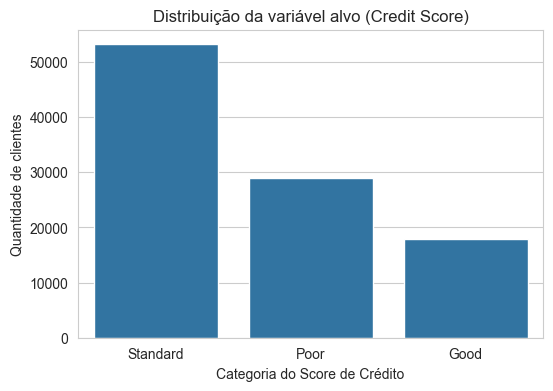

In [168]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='Credit_Score',
    order=df['Credit_Score'].value_counts().index
)

plt.title('Distribuição da variável alvo (Credit Score)')
plt.xlabel('Categoria do Score de Crédito')
plt.ylabel('Quantidade de clientes')

plt.show()

Observa-se que a classe Standard concentra a maior quantidade de registros, seguida pelas classes Poor e Good. Isso indica um desbalanceamento moderado entre as categorias, o que pode influenciar o desempenho dos modelos preditivos. Dessa forma, durante a etapa de modelagem, além da acurácia, serão avaliadas métricas como Precisão, Recall e F1-score para garantir uma análise mais completa do desempenho em cada classe.

6.2. Distribuição da idade

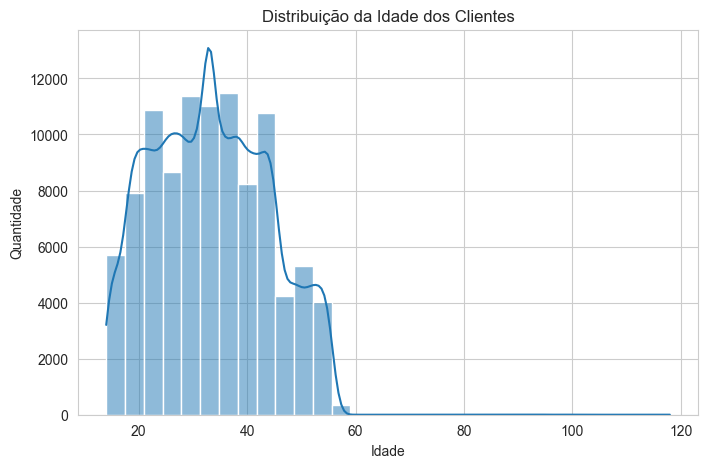

In [169]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Distribuição da Idade dos Clientes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

O histograma mostra como os clientes estão distribuídos em relação à idade. Observa-se uma maior concentração de indivíduos adultos, indicando que a maior parte da base pertence à população economicamente ativa. Essa análise ajuda a compreender o perfil demográfico do conjunto de dados.

6.3. Distribuição da renda anual

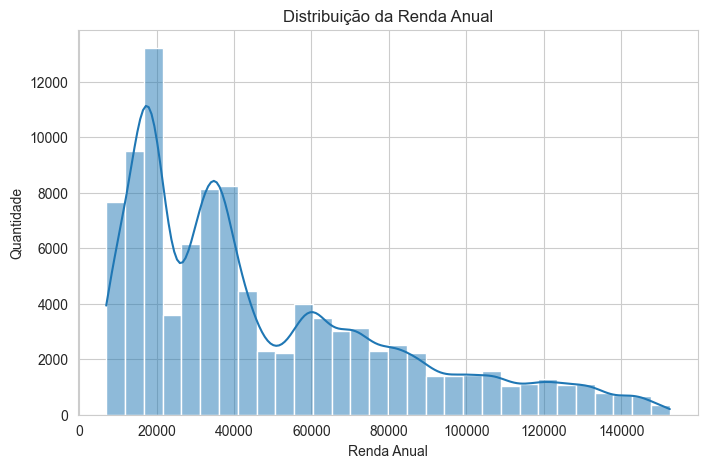

In [170]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual_Income"], bins=30, kde=True)

plt.title("Distribuição da Renda Anual")
plt.xlabel("Renda Anual")
plt.ylabel("Quantidade")

plt.show()

A distribuição da renda anual apresenta assimetria positiva, com maior concentração de clientes nas faixas de renda mais baixas e redução gradual da frequência conforme a renda aumenta. Esse comportamento é esperado em dados financeiros e sugere que a maior parte dos clientes possui rendimentos intermediários, enquanto rendas mais elevadas são menos frequentes.

6.4. Boxplot da renda anual

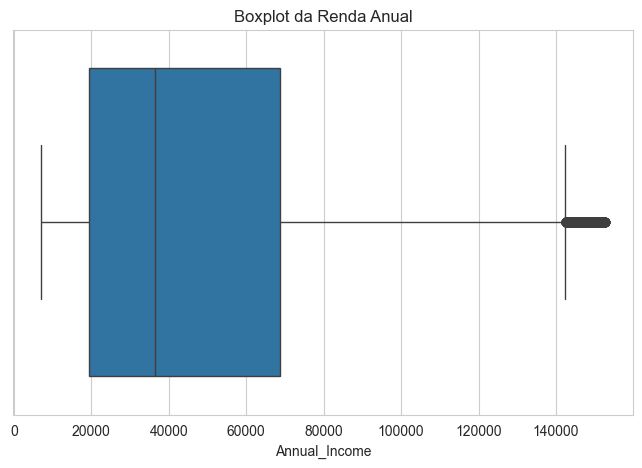

In [171]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Annual_Income"])

plt.title("Boxplot da Renda Anual")

plt.show()

O boxplot evidencia a distribuição da renda anual dos clientes, destacando a mediana, a dispersão dos dados e a amplitude dos valores. Após o tratamento dos outliers realizado na etapa de limpeza, observa-se uma distribuição mais consistente, sem valores extremos que possam distorcer as análises. Ainda assim, nota-se uma maior concentração de clientes em faixas de renda mais baixas, enquanto rendas mais elevadas aparecem com menor frequência, característica comum em bases de dados financeiras.

6.5. Score de crédito por idade

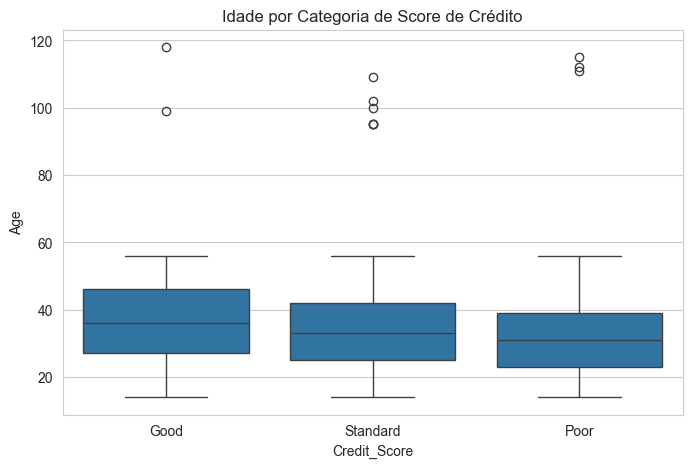

In [172]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Credit_Score",
    y="Age"
)

plt.title("Idade por Categoria de Score de Crédito")

plt.show()

Observa-se uma distribuição homogênea das idades entre as diferentes categorias de score de crédito. As medianas são próximas e a dispersão dos dados apresenta comportamento semelhante nos três grupos, sugerindo que a variável 'Age' possui baixo poder discriminatório quando analisada isoladamente. Dessa forma, a classificação do score de crédito parece estar mais relacionada a características financeiras do que à idade dos clientes.

6.6. Score de crédito por renda anual

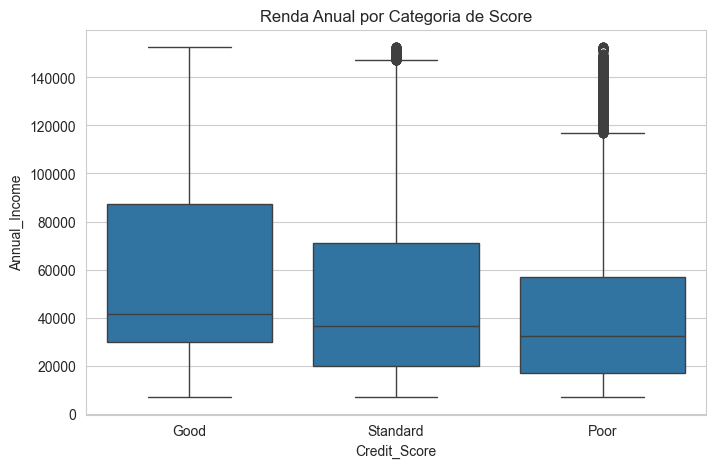

In [173]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Credit_Score",
    y="Annual_Income"
)

plt.title("Renda Anual por Categoria de Score")

plt.show()

Observa-se uma tendência de aumento da mediana da renda anual conforme melhora a classificação do score de crédito. No entanto, a ampla sobreposição entre os intervalos interquartis e a presença de valores elevados em todas as categorias sugerem que a variável 'Annual_Income' possui capacidade discriminatória moderada quando analisada isoladamente. Isso indica que a classificação do score depende da combinação de múltiplos fatores financeiros, e não apenas da renda do cliente.

6.7. Matriz de correlação

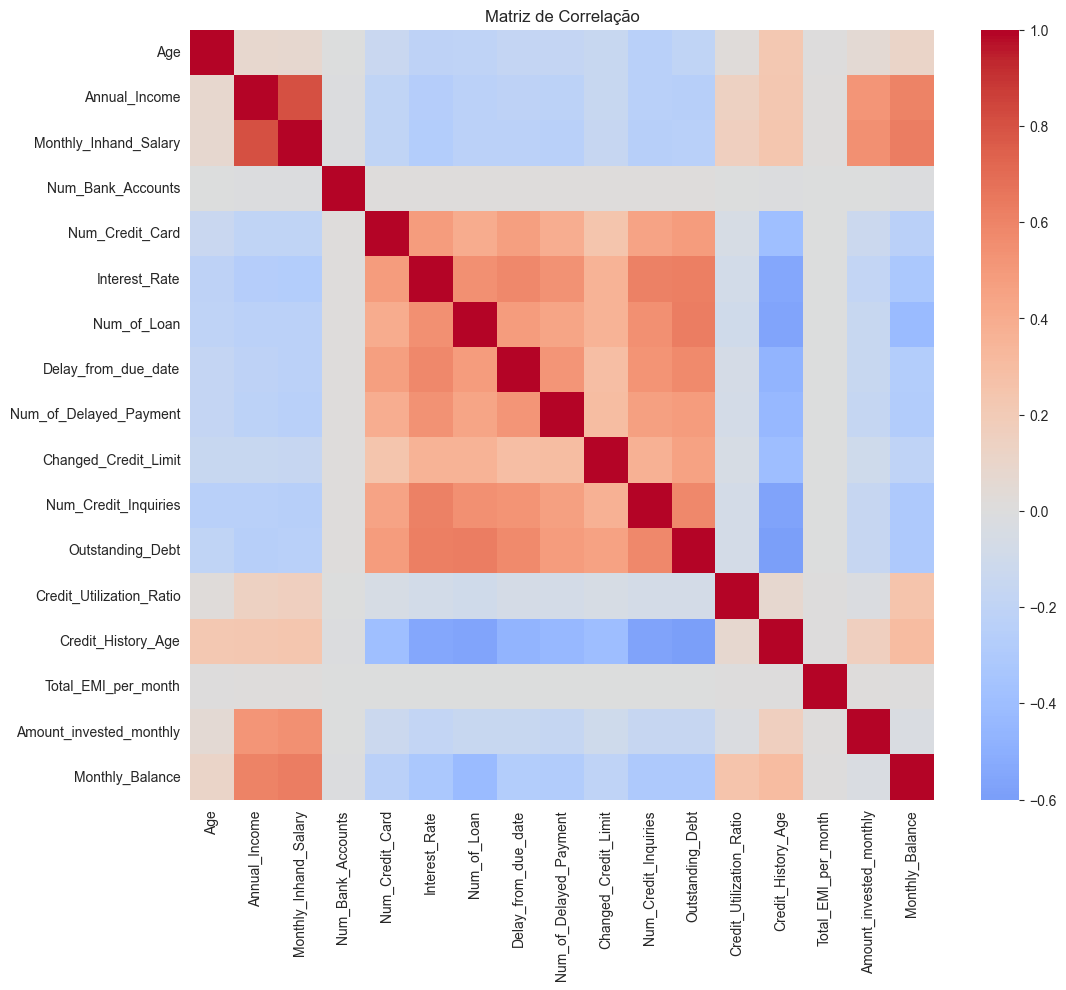

In [174]:
plt.figure(figsize=(12,10))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")

plt.show()

A matriz de correlação permite identificar o grau de associação linear entre as variáveis numéricas do conjunto de dados. Observam-se correlações positivas moderadas entre variáveis relacionadas à renda, salário mensal, investimentos e saldo disponível, indicando que esses fatores tendem a variar na mesma direção. Em contrapartida, variáveis associadas ao histórico de crédito e ao comportamento financeiro apresentam correlações negativas com indicadores de atraso e endividamento. De forma geral, não foram identificadas correlações extremamente elevadas entre as variáveis, sugerindo baixa multicolinearidade e indicando que cada atributo pode contribuir com informações relevantes para a etapa de modelagem.

7. Preparação

7.1. Seleção das variáveis

In [175]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [176]:
df = df.drop(columns=[
    "ID",
    "Customer_ID",
    "Name",
    "SSN",
    "Month"
])

In [177]:
df.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

Nesta etapa, foi realizada a seleção das variáveis que serão utilizadas na modelagem. O objetivo é remover atributos que não contribuem para a previsão do Score de Crédito, reduzindo ruídos e melhorando a eficiência dos algoritmos.
Foram removidas as seguintes colunas:
'ID' e 'Customer_ID': identificadores únicos dos registros e dos clientes, sem valor preditivo para o modelo.
'Name' e 'SSN': informações de identificação pessoal que não influenciam diretamente a classificação do score de crédito e poderiam introduzir viés na modelagem.
'Month': variável temporal que representa o mês do registro. Como este projeto não tem como objetivo realizar uma análise temporal, essa informação foi considerada pouco relevante para a tarefa de classificação.
As demais variáveis foram mantidas por representarem características demográficas, financeiras e comportamentais dos clientes, sendo potencialmente relevantes para a previsão do score de crédito. A coluna 'Credit_Score' foi preservada como variável alvo (target), enquanto as demais serão utilizadas como variáveis preditoras após as etapas de engenharia de atributos e codificação das variáveis categóricas.

7.2. Engenharia de atributos

7.2.1. Relação Dívida/ Renda

In [178]:
df['Debt_to_Income'] = (
    df['Outstanding_Debt'] / df['Annual_Income']
)

In [179]:
df[['Outstanding_Debt', 'Annual_Income', 'Debt_to_Income']].head()

,Outstanding_Debt,Annual_Income,Debt_to_Income
0,809.98,19114.12,0.042376
1,809.98,19114.12,0.042376
2,809.98,19114.12,0.042376
3,809.98,19114.12,0.042376
4,809.98,19114.12,0.042376


In [180]:
df['Debt_to_Income'].describe()

count    100000.000000
mean          0.060693
std           0.086875
min           0.000003
25%           0.010273
50%           0.028857
75%           0.069577
max           0.683252
Name: Debt_to_Income, dtype: float64

A variável 'Debt_to_Income' foi criada com o objetivo de representar o nível de endividamento do cliente em relação à sua renda anual.
Apenas analisar o valor absoluto da dívida pode não representar corretamente o risco financeiro, pois uma mesma dívida pode ter impactos diferentes dependendo da capacidade financeira do cliente.
A nova variável foi calculada pela razão entre o valor da dívida pendente ('Outstanding_Debt') e a renda anual ('Annual_Income'):
Valores mais altos dessa proporção podem indicar maior comprometimento financeiro e, consequentemente, maior risco de inadimplência.
Após a criação da variável, foi realizada uma análise estatística para verificar sua distribuição e identificar possíveis valores inconsistentes. A variável apresentou valores entre aproximadamente 0 e 0,68, indicando que os dados estão dentro de uma faixa coerente.

7.2.2. Comprometimento da renda com parcelas

In [181]:
df['EMI_to_Salary'] = (
    df['Total_EMI_per_month'] / df['Monthly_Inhand_Salary']
)

In [182]:
df[['Total_EMI_per_month', 'Monthly_Inhand_Salary', 'EMI_to_Salary']].head()

,Total_EMI_per_month,Monthly_Inhand_Salary,EMI_to_Salary
0,49.574949,1824.843333,0.027167
1,49.574949,3093.745000,0.016024
2,49.574949,3093.745000,0.016024
3,49.574949,3093.745000,0.016024
4,49.574949,1824.843333,0.027167


In [183]:
df['EMI_to_Salary'].describe()

count    100000.000000
mean          0.582484
std           4.710086
min           0.000000
25%           0.012089
50%           0.024848
75%           0.043536
max         227.739318
Name: EMI_to_Salary, dtype: float64

In [184]:
(df['EMI_to_Salary'] > 1).sum()

np.int64(3043)

In [185]:
df.loc[df['EMI_to_Salary'] > 1, 
       ['Total_EMI_per_month', 'Monthly_Inhand_Salary', 'EMI_to_Salary']].head()

,Total_EMI_per_month,Monthly_Inhand_Salary,EMI_to_Salary
40,15015.0,3093.745000,4.853341
45,15515.0,5988.705000,2.590710
51,23834.0,10469.207759,2.276581
52,32662.0,10469.207759,3.119816
76,16415.0,2825.233333,5.810140


A variável 'EMI_to_Salary' foi criada para representar o comprometimento da renda mensal do cliente com pagamentos de empréstimos.
A variável foi calculada pela razão entre o valor total das parcelas mensais ('Total_EMI_per_month') e o salário mensal disponível ('Monthly_Inhand_Salary'):
Essa relação permite identificar clientes que possuem maior comprometimento da renda com empréstimos, podendo indicar maior risco financeiro.
Durante a análise da distribuição da variável, foram identificados valores superiores a 1, indicando casos em que o valor das parcelas mensais supera o salário informado.
Esses valores não foram removidos ou limitados neste momento, pois podem representar clientes com alto nível de endividamento ou possíveis características reais do comportamento financeiro. A influência dessa variável será avaliada posteriormente durante a seleção de atributos e treinamento dos modelos.

7.2.3. Relação Investimento / Renda

In [186]:
df['Investment_to_Income'] = (
    df['Amount_invested_monthly'] /
    df['Monthly_Inhand_Salary']
)

In [187]:
df[['Amount_invested_monthly',
    'Monthly_Inhand_Salary',
    'Investment_to_Income']].head()

,Amount_invested_monthly,Monthly_Inhand_Salary,Investment_to_Income
0,80.415295,1824.843333,0.044067
1,118.280222,3093.745000,0.038232
2,81.699521,3093.745000,0.026408
3,199.458074,3093.745000,0.064471
4,41.420153,1824.843333,0.022698


In [188]:
df['Investment_to_Income'].describe()

count    100000.000000
mean          0.054201
std           0.039746
min           0.000000
25%           0.024961
50%           0.042930
75%           0.075030
max           0.607194
Name: Investment_to_Income, dtype: float64

A variável 'Investment_to_Income' foi criada para representar a proporção da renda mensal destinada a investimentos.
Apenas analisar o valor absoluto investido pode ser limitado, pois clientes com rendas diferentes possuem capacidades diferentes de investimento. Por isso, foi criada uma relação entre o valor investido mensalmente ('Amount_invested_monthly') e a renda mensal disponível ('Monthly_Inhand_Salary').
A variável foi calculada pela fórmula:
Valores maiores indicam que uma parcela maior da renda do cliente é direcionada para investimentos, podendo representar maior capacidade financeira e estabilidade.
Após a criação da variável, foi analisada sua distribuição estatística. Os valores encontrados permaneceram em uma faixa coerente, sem necessidade de tratamento adicional neste momento.

7.2.4. Salário Disponível / Recebido

In [189]:
df['Balance_to_Income'] = (
    df['Monthly_Balance'] /
    df['Monthly_Inhand_Salary']
)

In [190]:
df[['Monthly_Balance',
    'Monthly_Inhand_Salary',
    'Balance_to_Income']].head()

,Monthly_Balance,Monthly_Inhand_Salary,Balance_to_Income
0,312.494089,1824.843333,0.171244
1,284.629162,3093.745000,0.092001
2,331.209863,3093.745000,0.107058
3,223.451310,3093.745000,0.072227
4,341.489231,1824.843333,0.187133


In [191]:
df['Balance_to_Income'].describe()

count    1.000000e+05
mean     1.403002e-01
std      9.437853e-02
min      7.508754e-07
25%      8.145827e-02
50%      1.140846e-01
75%      1.757017e-01
max      8.764869e-01
Name: Balance_to_Income, dtype: float64

A variável 'Balance_to_Income' foi criada para representar a relação entre o saldo mensal disponível e a renda mensal do cliente.
O valor absoluto do saldo pode não representar adequadamente a situação financeira, pois clientes com diferentes níveis de renda possuem diferentes capacidades de manutenção de saldo.
A variável foi calculada pela razão entre o saldo mensal ('Monthly_Balance') e a renda mensal disponível ('Monthly_Inhand_Salary'):
Valores maiores indicam que uma parcela maior da renda permanece disponível como saldo, podendo representar maior capacidade financeira.
Após a criação da variável, foi realizada uma análise estatística para avaliar sua distribuição. Os valores encontrados permaneceram em uma faixa coerente, não sendo necessário realizar tratamentos adicionais.

7.3. Preparação dos dados

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Occupation                100000 non-null  object 
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     100000 non-null  float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  float64
 6   Interest_Rate             100000 non-null  float64
 7   Num_of_Loan               100000 non-null  float64
 8   Type_of_Loan              100000 non-null  object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    100000 non-null  float64
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  float64
 13  Credit_Mix                100000 non-null  ob

In [193]:
df.select_dtypes(include='object').columns

Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [194]:
df['Credit_Mix'] = df['Credit_Mix'].map({
    'Bad': 0,
    'Standard': 1,
    'Good': 2
})

In [195]:
df['Credit_Mix'].value_counts()

Credit_Mix
1.0    36479
2.0    24337
0.0    18989
Name: count, dtype: int64

In [196]:
df['Credit_Mix'].isna().sum()

np.int64(20195)

In [197]:
df['Credit_Mix'].value_counts(dropna=False)

Credit_Mix
1.0    36479
2.0    24337
NaN    20195
0.0    18989
Name: count, dtype: int64

In [198]:
df['Credit_Mix'] = df['Credit_Mix'].fillna(-1)

In [199]:
df['Credit_Mix'].value_counts()

Credit_Mix
 1.0    36479
 2.0    24337
-1.0    20195
 0.0    18989
Name: count, dtype: int64

A variável 'Credit_Mix' representa a combinação de produtos de crédito do cliente e possui uma relação ordinal entre suas categorias.
A variável já estava previamente codificada numericamente, mantendo uma ordem de qualidade de crédito:
0: menor qualidade de crédito
1: qualidade intermediária
2: maior qualidade de crédito
Durante a análise dos dados, foram identificados valores ausentes em aproximadamente 20% dos registros. Como a ausência da informação também pode representar uma característica do cliente, os valores nulos foram substituídos por -1, mantendo-os como uma categoria separada.
Dessa forma, o modelo poderá aprender se a ausência dessa informação possui relação com o 'Credit_Score'.

In [200]:
df['Payment_of_Min_Amount'].value_counts(dropna=False)

Payment_of_Min_Amount
Yes        52326
No         35667
Unknown    12007
Name: count, dtype: int64

In [201]:
df = pd.get_dummies(
    df,
    columns=['Payment_of_Min_Amount'],
    dtype=int
)

In [202]:
df.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income,EMI_to_Salary,Investment_to_Income,Balance_to_Income,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Unknown,Payment_of_Min_Amount_Yes
0,23.0,Scientist,19114.12,1824.843333,3,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,High_spent_Small_value_payments,312.494089,Good,0.042376,0.027167,0.044067,0.171244,1,0,0
1,23.0,Scientist,19114.12,3093.745000,3,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,...,Low_spent_Large_value_payments,284.629162,Good,0.042376,0.016024,0.038232,0.092001,1,0,0
2,33.0,Scientist,19114.12,3093.745000,3,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,...,Low_spent_Medium_value_payments,331.209863,Good,0.042376,0.016024,0.026408,0.107058,1,0,0
3,23.0,Scientist,19114.12,3093.745000,3,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,...,Low_spent_Small_value_payments,223.451310,Good,0.042376,0.016024,0.064471,0.072227,1,0,0
4,23.0,Scientist,19114.12,1824.843333,3,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,...,High_spent_Medium_value_payments,341.489231,Good,0.042376,0.027167,0.022698,0.187133,1,0,0


A variável 'Payment_of_Min_Amount' possuía informações categóricas relacionadas ao pagamento do valor mínimo da fatura, contendo três possíveis categorias: "Yes", "No" e "Unknown".
Como os algoritmos de Machine Learning trabalham com valores numéricos, foi aplicada a técnica de One-Hot Encoding utilizando a função 'pd.get_dummies()' do Pandas.
Essa transformação converte cada categoria em uma nova variável binária, onde o valor 1 indica a presença daquela categoria e o valor 0 indica sua ausência.

In [203]:
df.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Debt_to_Income', 'EMI_to_Salary',
       'Investment_to_Income', 'Balance_to_Income', 'Payment_of_Min_Amount_No',
       'Payment_of_Min_Amount_Unknown', 'Payment_of_Min_Amount_Yes'],
      dtype='object')

In [204]:
for coluna in ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_Behaviour', 'Credit_Score']:
    print(f'\n{coluna}')
    print(df[coluna].unique())


Occupation
['Scientist' 'Unknown' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer'
 'Lawyer' 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant'
 'Musician' 'Mechanic' 'Writer' 'Architect']

Type_of_Loan
['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'
 'Credit-Builder Loan' 'Auto Loan, Auto Loan, and Not Specified' ...
 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan'
 'Payday Loan, Student Loan, Mortgage Loan, and Not Specified'
 'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan']

Credit_Mix
[-1.  2.  1.  0.]

Payment_Behaviour
['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' 'Unknown'
 'High_spent_Large_value_payments']

Credit_Score
['Good' 'Standard' 'Poor']


In [205]:
df['Type_of_Loan'].head(10)

0    Auto Loan, Credit-Builder Loan, Personal Loan,...
1    Auto Loan, Credit-Builder Loan, Personal Loan,...
2    Auto Loan, Credit-Builder Loan, Personal Loan,...
3    Auto Loan, Credit-Builder Loan, Personal Loan,...
4    Auto Loan, Credit-Builder Loan, Personal Loan,...
5    Auto Loan, Credit-Builder Loan, Personal Loan,...
6    Auto Loan, Credit-Builder Loan, Personal Loan,...
7    Auto Loan, Credit-Builder Loan, Personal Loan,...
8                                  Credit-Builder Loan
9                                  Credit-Builder Loan
Name: Type_of_Loan, dtype: object

In [206]:
df['Type_of_Loan'].nunique()

6261

In [207]:
loan_types = set()

for loans in df['Type_of_Loan']:
    loans = loans.replace(' and ', ', ')

    for loan in loans.split(','):
        loan = loan.strip()
        
        if loan and loan != 'Not Specified':
            loan_types.add(loan)

sorted(loan_types)

['Auto Loan',
 'Credit-Builder Loan',
 'Debt Consolidation Loan',
 'Home Equity Loan',
 'Mortgage Loan',
 'No Loan',
 'Payday Loan',
 'Personal Loan',
 'Student Loan']

In [208]:
loan_types = [
    'Auto Loan',
    'Credit-Builder Loan',
    'Debt Consolidation Loan',
    'Home Equity Loan',
    'Mortgage Loan',
    'No Loan',
    'Payday Loan',
    'Personal Loan',
    'Student Loan'
]

for loan in loan_types:
    column_name = (
        loan.lower()
        .replace('-', '_')
        .replace(' ', '_')
    )

    df[f'loan_{column_name}'] = df['Type_of_Loan'].str.contains(
        loan,
        regex=False
    ).astype(int)

In [209]:
df.filter(like='loan_').head()

,loan_auto_loan,loan_credit_builder_loan,loan_debt_consolidation_loan,loan_home_equity_loan,loan_mortgage_loan,loan_no_loan,loan_payday_loan,loan_personal_loan,loan_student_loan
0,1,1,0,1,0,0,0,1,0
1,1,1,0,1,0,0,0,1,0
2,1,1,0,1,0,0,0,1,0
3,1,1,0,1,0,0,0,1,0
4,1,1,0,1,0,0,0,1,0


In [210]:
df.drop(columns='Type_of_Loan', inplace=True)

In [211]:
'Type_of_Loan' in df.columns

False

A variável 'Type_of_Loan' apresentava múltiplos tipos de empréstimo combinados em uma única célula, o que resultava em mais de 6 mil combinações distintas. A aplicação direta de One-Hot Encoding geraria um número excessivo de variáveis e aumentaria significativamente a dimensionalidade do conjunto de dados.
Para preservar a informação de forma mais eficiente, cada tipo de empréstimo foi separado e transformado em uma variável binária (0 ou 1), indicando a presença ou ausência daquele tipo de empréstimo para cada cliente. Após a criação dessas novas variáveis, a coluna original foi removida por não ser mais necessária.

In [212]:
df = pd.get_dummies(
    df,
    columns=['Payment_Behaviour'],
    dtype=int
)

In [213]:
df.filter(like='Payment_Behaviour').head()

,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Payment_Behaviour_Unknown
0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0
2,0,0,0,0,1,0,0
3,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0


A variável 'Payment_Behaviour' é categórica nominal e descreve o padrão de gastos e pagamentos do cliente. Como não existe uma relação de ordem entre suas categorias, foi aplicada a técnica de 'One-Hot Encoding', transformando cada categoria em uma variável binária.
A categoria 'Unknown' foi mantida para preservar a informação de ausência de dados, evitando a introdução de viés por meio de imputação.

In [215]:
df['Credit_Score'] = df['Credit_Score'].map({
    'Poor': 0,
    'Standard': 1,
    'Good': 2
})

In [216]:
df['Credit_Score'].value_counts().sort_index()

Credit_Score
0    28998
1    53174
2    17828
Name: count, dtype: int64

In [218]:
df = pd.get_dummies(
    df,
    columns=['Occupation'],
    dtype=int
)

In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 58 columns):
 #   Column                                              Non-Null Count   Dtype  
---  ------                                              --------------   -----  
 0   Age                                                 100000 non-null  float64
 1   Annual_Income                                       100000 non-null  float64
 2   Monthly_Inhand_Salary                               100000 non-null  float64
 3   Num_Bank_Accounts                                   100000 non-null  int64  
 4   Num_Credit_Card                                     100000 non-null  float64
 5   Interest_Rate                                       100000 non-null  float64
 6   Num_of_Loan                                         100000 non-null  float64
 7   Delay_from_due_date                                 100000 non-null  int64  
 8   Num_of_Delayed_Payment                              100000 non-nu

Após as etapas de limpeza, tratamento de valores ausentes, tratamento de outliers, engenharia de atributos e codificação das variáveis categóricas, o conjunto de dados encontra-se pronto para a etapa de modelagem preditiva.
Nesta fase, todas as variáveis de entrada encontram-se em formato numérico, sem valores ausentes, permitindo a aplicação de algoritmos de Machine Learning. A próxima etapa consiste na separação das variáveis preditoras e da variável alvo, na divisão dos dados em conjuntos de treino e teste e no treinamento dos modelos de classificação para previsão do score de crédito.

8. Modelagem

9. Avaliação

10. Conclusão